# Medical Appointment No-Show Prediction & Demand Forecasting
## Notebook 1: Exploratory Data Analysis (EDA)

**Domain:** Healthcare Operations & Resource Management  
**Facility:** University of Vale do Itajaí - CER (Rehabilitation Center), Southern Brazil  
**Dataset:** 109,593 appointments × 26 columns

### Objective
Explore the dataset to understand patterns in patient no-shows (~31.8% rate) and appointment demand across specialties, locations, and weather conditions.

In [1]:
# ── Section 1: Import Libraries ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('Libraries imported successfully!')

Libraries imported successfully!


In [2]:
# ── Load Dataset ─────────────────────────────────────────────────────────────
import sys, os
sys.path.append(os.path.abspath('..'))
from src.preprocessing import load_data

df = load_data()
print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\nColumn names:\n{list(df.columns)}')
df.head()

Dataset loaded: 109593 rows × 26 columns
Dataset shape: 109,593 rows × 26 columns

Column names:
['specialty', 'appointment_time', 'gender', 'no_show', 'disability', 'place', 'appointment_shift', 'age', 'under_12', 'over_60', 'needs_companion', 'avg_temp', 'rain', 'max_temp', 'max_rain', 'rainy_day_before', 'storm_day_before', 'rain_intensity', 'heat_intensity', 'appointment_date_continuous', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'Scholarship', 'SMSreceived']


,specialty,appointment_time,gender,no_show,disability,place,appointment_shift,age,under_12,over_60,...,storm_day_before,rain_intensity,heat_intensity,appointment_date_continuous,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMSreceived
0,psychotherapy,17,F,yes,intellectual,Lake Marvinville,afternoon,9.0,1,0,...,1,no_rain,warm,2020-01-01,0,0,0,0,0,0
1,NaN,7,M,no,intellectual,ITAPEMA,morning,11.0,1,0,...,1,no_rain,cold,2020-01-01,0,0,0,0,0,0
2,speech therapy,16,M,no,intellectual,ITAJAÍ,afternoon,8.0,1,0,...,1,no_rain,warm,2020-01-01,0,0,0,0,0,0
3,speech therapy,14,M,yes,intellectual,Sarahside,afternoon,9.0,1,0,...,1,moderate,mild,2020-01-01,0,0,0,0,0,1
4,physiotherapy,8,M,no,motor,ITAJAÍ,morning,NaN,0,0,...,1,no_rain,mild,2020-01-01,0,0,0,0,0,0


## Section 2: Initial Data Inspection & Summary Statistics

In [3]:
# Data types and info
print('='*60)
print('DATA TYPES')
print('='*60)
print(df.dtypes)
print(f'\n{"="*60}')
print('DATASET INFO')
print('='*60)
df.info()

DATA TYPES
specialty                          str
appointment_time                 int64
gender                             str
no_show                            str
disability                         str
place                              str
appointment_shift                  str
age                            float64
under_12                         int64
over_60                          int64
needs_companion                  int64
avg_temp                       float64
rain                           float64
max_temp                       float64
max_rain                       float64
rainy_day_before                 int64
storm_day_before                 int64
rain_intensity                     str
heat_intensity                     str
appointment_date_continuous        str
Hipertension                     int64
Diabetes                         int64
Alcoholism                       int64
Handcap                          int64
Scholarship                      int64
SMSreceived   

In [4]:
# Summary statistics for numeric columns
print('NUMERIC SUMMARY')
df.describe()

NUMERIC SUMMARY


,appointment_time,age,under_12,over_60,needs_companion,avg_temp,rain,max_temp,max_rain,rainy_day_before,storm_day_before,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMSreceived
count,109593.000000,86633.000000,109593.000000,109593.000000,109593.000000,107382.000000,107348.000000,107366.000000,107330.000000,109593.000000,109593.000000,109593.000000,109593.000000,109593.000000,109593.000000,109593.000000,109593.000000
mean,12.120966,18.632138,0.446424,0.071328,0.519823,20.346642,0.183537,24.032910,2.048093,0.937396,0.937533,0.058088,0.023952,0.018541,0.009116,0.055113,0.311808
std,3.281623,17.666999,0.497124,0.257372,0.499609,3.446079,0.416267,3.959696,4.352247,0.242251,0.242004,0.233910,0.152901,0.134899,0.095040,0.228202,0.463234
min,7.000000,2.000000,0.000000,0.000000,0.000000,8.940000,0.000000,13.300000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9.000000,8.000000,0.000000,0.000000,0.000000,18.060000,0.000000,21.400000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,13.000000,12.000000,0.000000,0.000000,1.000000,20.600000,0.010000,23.900000,0.200000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,15.000000,18.000000,1.000000,0.000000,1.000000,22.720000,0.150000,26.800000,1.900000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,18.000000,110.000000,1.000000,1.000000,1.000000,28.010000,4.770000,35.400000,45.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
# Summary statistics for categorical columns
print('CATEGORICAL SUMMARY')
df.describe(include='object')

CATEGORICAL SUMMARY


,specialty,gender,no_show,disability,place,appointment_shift,rain_intensity,heat_intensity,appointment_date_continuous
count,89466,109593,109593,92573,98054,109593,109593,109593,109593
unique,8,3,2,2,26289,2,4,5,498
top,psychotherapy,M,no,intellectual,ITAJAÍ,afternoon,no_rain,mild,2021-04-02
freq,28645,82269,74761,62852,20515,59334,76415,46903,1512


## Section 3: Missing Value Analysis

**Expected missing values:**
- `age`: ~21%
- `specialty`: ~18%
- `disability`: ~15%
- `place`: ~10.5%
- Weather columns: ~2%
- `no_show`: 0% (no missing target values)

Columns with missing values: 8
Total missing cells: 80,592


,Missing Count,Missing %
age,22960,20.95
specialty,20127,18.37
disability,17020,15.53
place,11539,10.53
max_rain,2263,2.06
rain,2245,2.05
max_temp,2227,2.03
avg_temp,2211,2.02


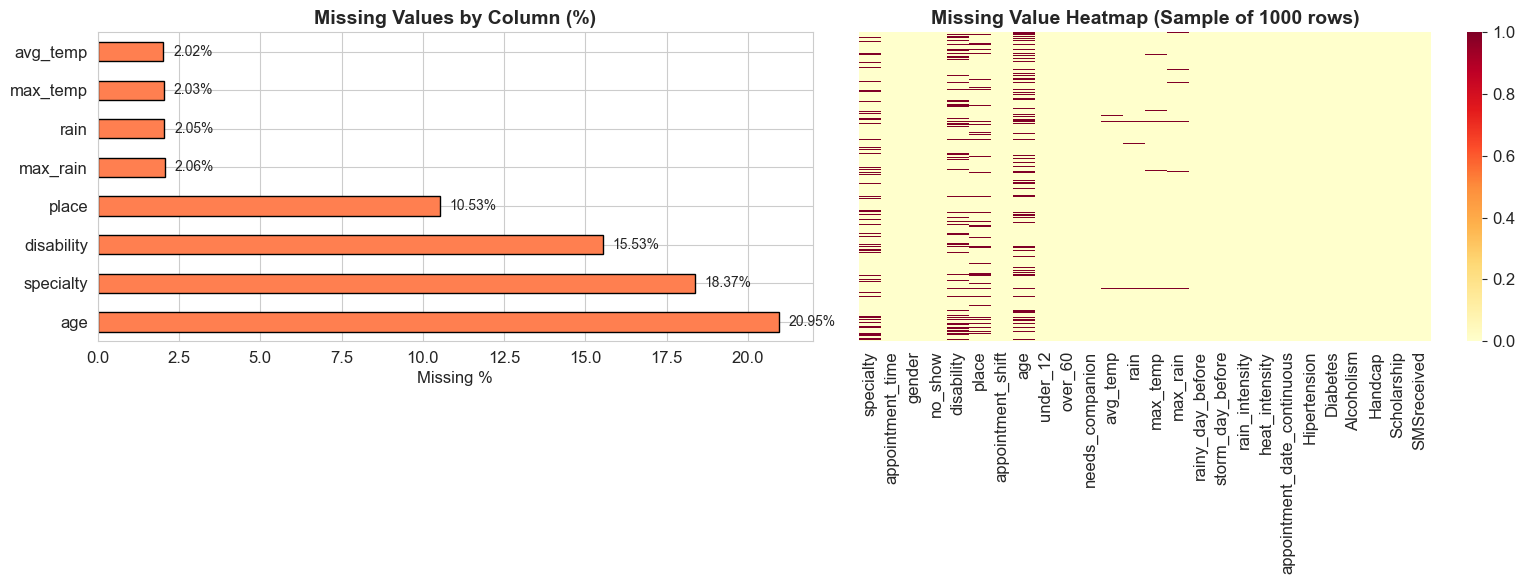

In [6]:
# ── Missing Value Analysis ────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(f'Columns with missing values: {len(missing_df)}')
print(f'Total missing cells: {df.isnull().sum().sum():,}')
display(missing_df)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of missing percentages
if len(missing_df) > 0:
    missing_df['Missing %'].plot(kind='barh', ax=axes[0], color='coral', edgecolor='black')
    axes[0].set_title('Missing Values by Column (%)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Missing %')
    for i, v in enumerate(missing_df['Missing %']):
        axes[0].text(v + 0.3, i, f'{v}%', va='center', fontsize=10)

# Heatmap of missing values (sample)
sample = df.sample(min(1000, len(df)), random_state=42)
sns.heatmap(sample.isnull(), cbar=True, yticklabels=False, cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Missing Value Heatmap (Sample of 1000 rows)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Section 4: Target Variable - No-Show Distribution

The target variable `no_show` indicates whether a patient missed their appointment (Yes) or attended (No).  
Expected no-show rate: **~31.8%** — significantly higher than the typical 10-20% in healthcare.

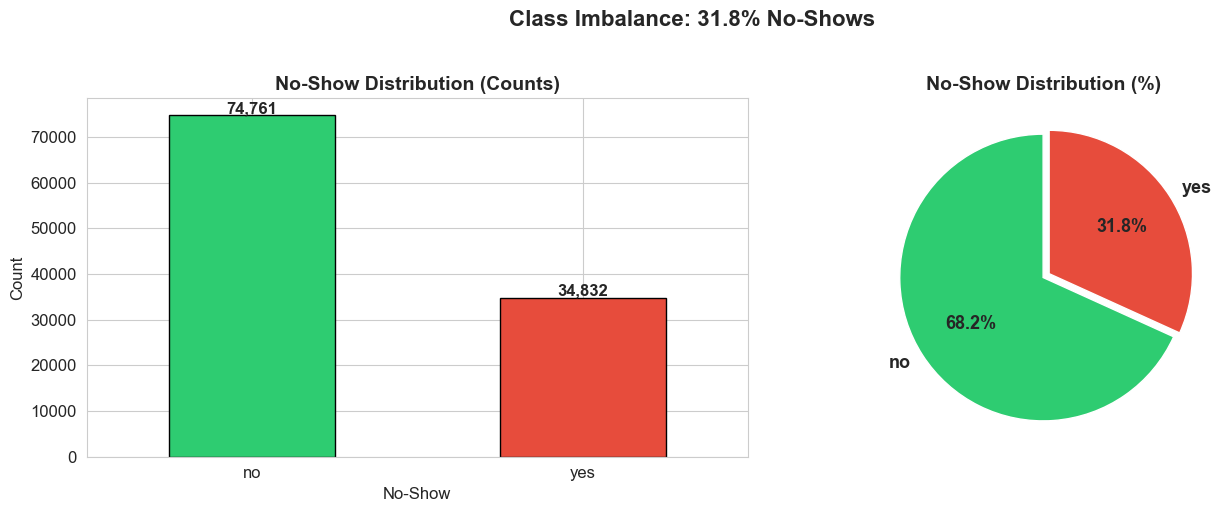


No-Show Rate: 31.8%
⚠️ Class imbalance detected — will need SMOTE / class weights during modeling.


In [7]:
# ── Target Variable Distribution ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
target_counts = df['no_show'].value_counts()
colors = ['#2ecc71', '#e74c3c']
target_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('No-Show Distribution (Counts)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('No-Show')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
for i, v in enumerate(target_counts):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=12, fontweight='bold')

# Pie chart
target_pct = df['no_show'].value_counts(normalize=True) * 100
axes[1].pie(target_pct, labels=target_pct.index, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0, 0.05),
            textprops={'fontsize': 13, 'fontweight': 'bold'})
axes[1].set_title('No-Show Distribution (%)', fontsize=14, fontweight='bold')

plt.suptitle(f'Class Imbalance: {target_pct.get("yes", target_pct.iloc[1]):.1f}% No-Shows', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\nNo-Show Rate: {target_pct.get("yes", 0):.1f}%')
print('⚠️ Class imbalance detected — will need SMOTE / class weights during modeling.')

## Section 5: EDA - Patient Demographics & Health Conditions

Analyze no-show rates across:
- **Demographics:** gender, age groups (under_12, over_60), disability, needs_companion
- **Health conditions:** Hipertension, Diabetes, Alcoholism, Handcap, Scholarship, SMSreceived

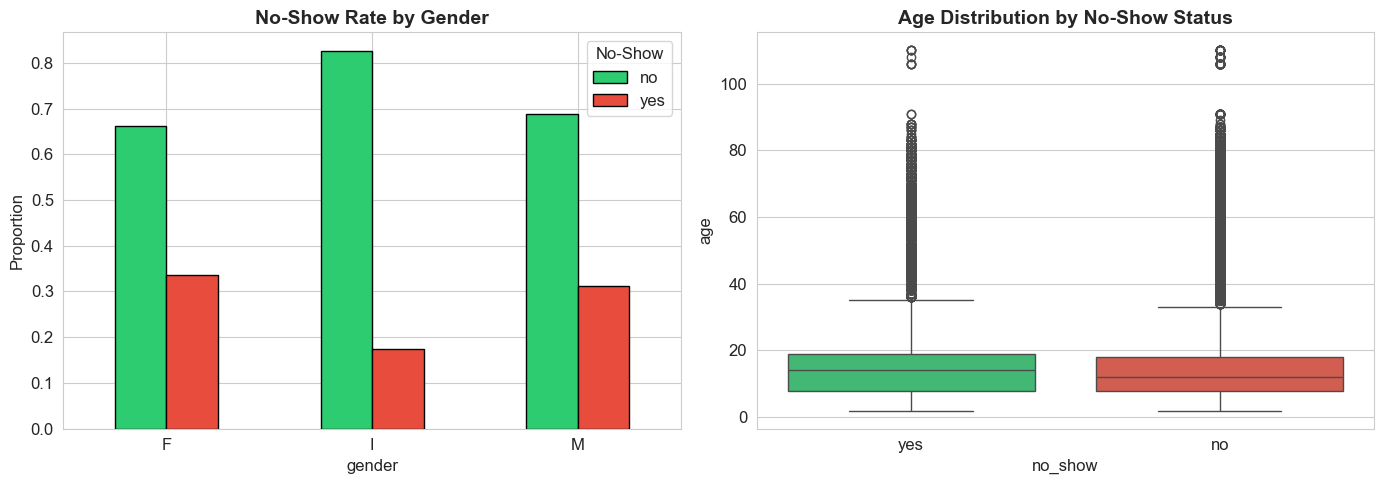

In [8]:
# ── No-Show Rate by Gender ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender distribution
if 'gender' in df.columns:
    gender_noshow = df.groupby('gender')['no_show'].value_counts(normalize=True).unstack()
    gender_noshow.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
    axes[0].set_title('No-Show Rate by Gender', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Proportion')
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
    axes[0].legend(title='No-Show')

# Age distribution by no-show
if 'age' in df.columns:
    df_age = df.dropna(subset=['age'])
    sns.boxplot(data=df_age, x='no_show', y='age', ax=axes[1], palette=colors)
    axes[1].set_title('Age Distribution by No-Show Status', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

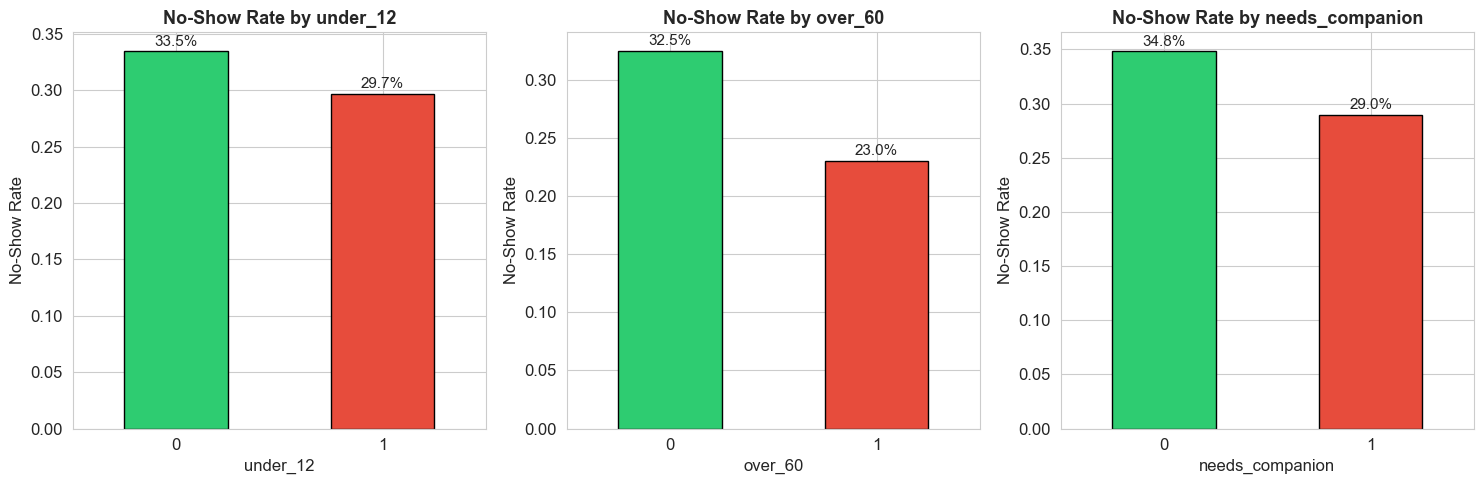

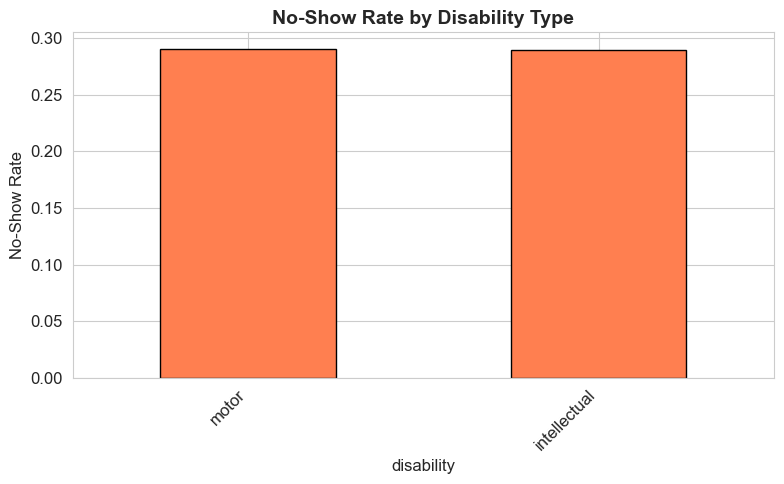

In [10]:
# ── No-Show Rate by Age Flags & Patient Characteristics ──────────────────────
# Helper: compute no-show rate per group (handles string dtype)
def noshow_rate_by(df, group_col, target='no_show', yes_val='yes'):
    return df.groupby(group_col)[target].apply(lambda x: (x == yes_val).sum() / len(x))

binary_patient_cols = ['under_12', 'over_60', 'needs_companion']
existing_cols = [c for c in binary_patient_cols if c in df.columns]

if existing_cols:
    fig, axes = plt.subplots(1, len(existing_cols), figsize=(5 * len(existing_cols), 5))
    if len(existing_cols) == 1:
        axes = [axes]
    for i, col in enumerate(existing_cols):
        noshow_rate = noshow_rate_by(df, col)
        noshow_rate.plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c'], edgecolor='black')
        axes[i].set_title(f'No-Show Rate by {col}', fontsize=13, fontweight='bold')
        axes[i].set_ylabel('No-Show Rate')
        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)
        for j, v in enumerate(noshow_rate):
            axes[i].text(j, v + 0.005, f'{v:.1%}', ha='center', fontsize=11)
    plt.tight_layout()
    plt.show()

# Disability (categorical)
if 'disability' in df.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    disability_noshow = noshow_rate_by(df.dropna(subset=['disability']), 'disability').sort_values(ascending=False)
    disability_noshow.plot(kind='bar', ax=ax, color='coral', edgecolor='black')
    ax.set_title('No-Show Rate by Disability Type', fontsize=14, fontweight='bold')
    ax.set_ylabel('No-Show Rate')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

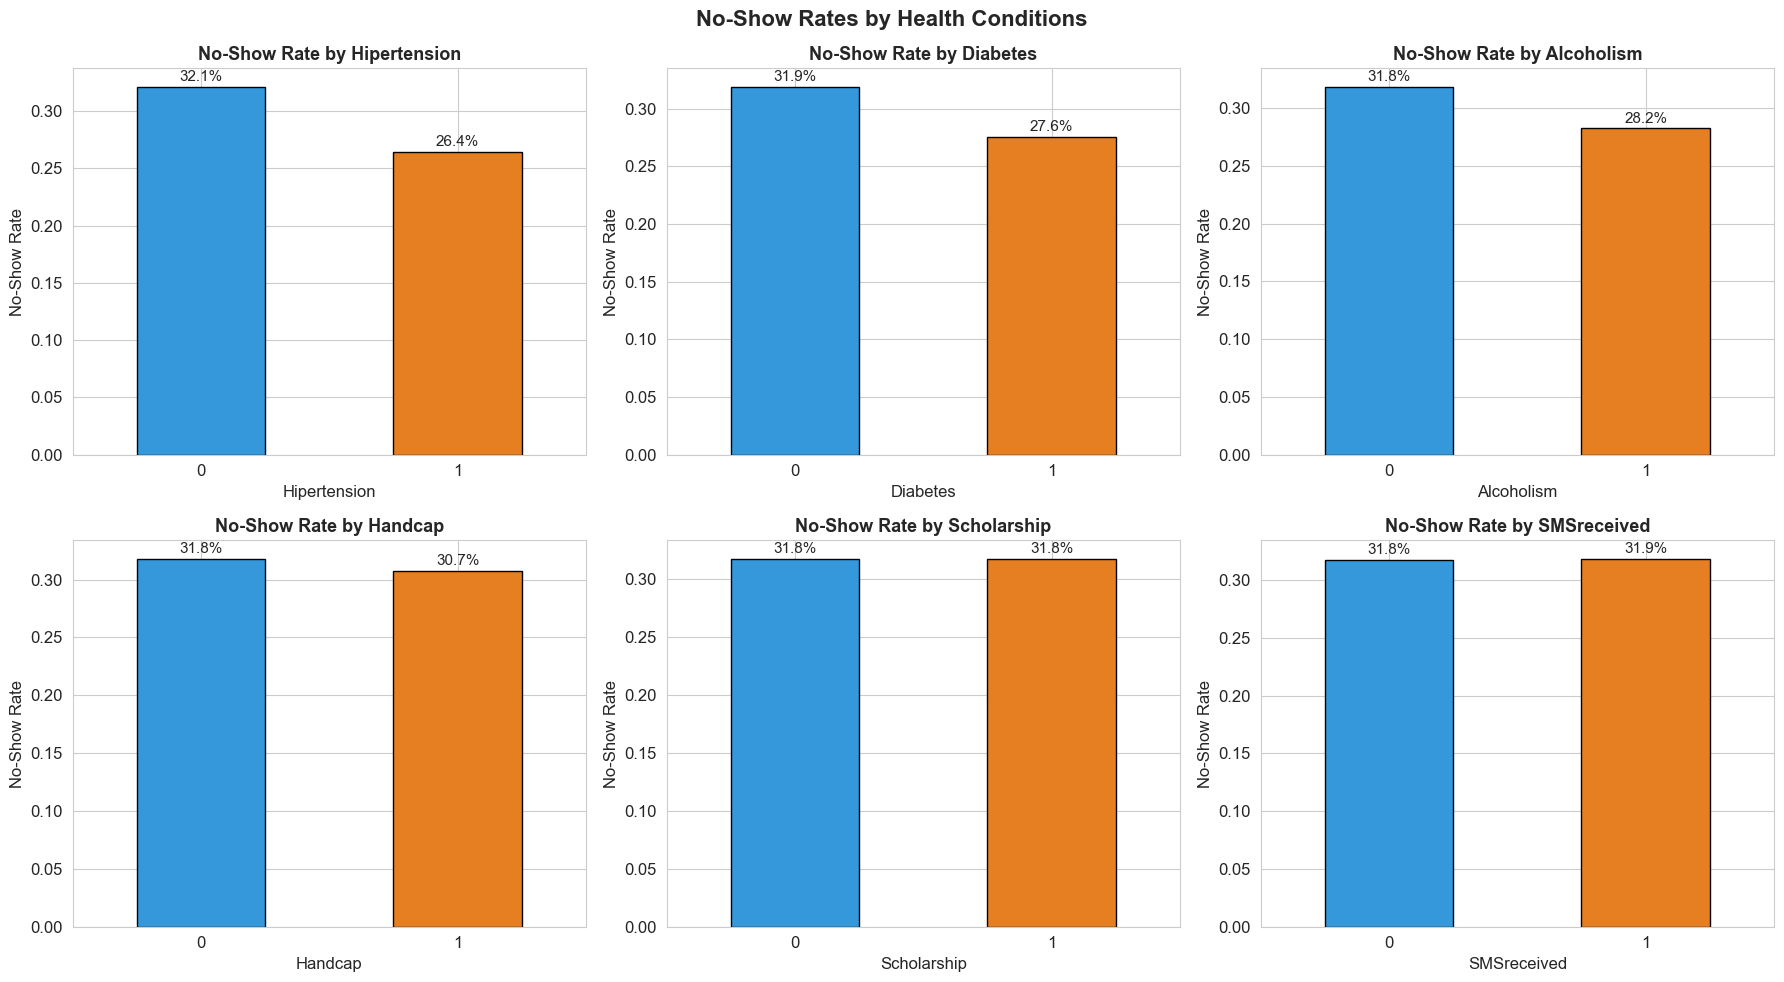

In [11]:
# ── No-Show Rate by Health Conditions ─────────────────────────────────────────
health_cols = ['Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'Scholarship', 'SMSreceived']
existing_health = [c for c in health_cols if c in df.columns]

if existing_health:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    for i, col in enumerate(existing_health):
        nr = noshow_rate_by(df, col)
        nr.plot(kind='bar', ax=axes[i], color=['#3498db', '#e67e22'], edgecolor='black')
        axes[i].set_title(f'No-Show Rate by {col}', fontsize=13, fontweight='bold')
        axes[i].set_ylabel('No-Show Rate')
        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)
        for j, v in enumerate(nr):
            axes[i].text(j, v + 0.005, f'{v:.1%}', ha='center', fontsize=11)
    for idx in range(len(existing_health), len(axes)):
        axes[idx].set_visible(False)
    plt.suptitle('No-Show Rates by Health Conditions', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Section 6: EDA - Appointment Patterns by Specialty, Location & Time

Explore no-show rates across:
- **Specialties** (physiotherapy, psychotherapy, speech therapy, occupational therapy)
- **Cities** (13 locations in the service region)
- **Appointment shifts** and temporal patterns

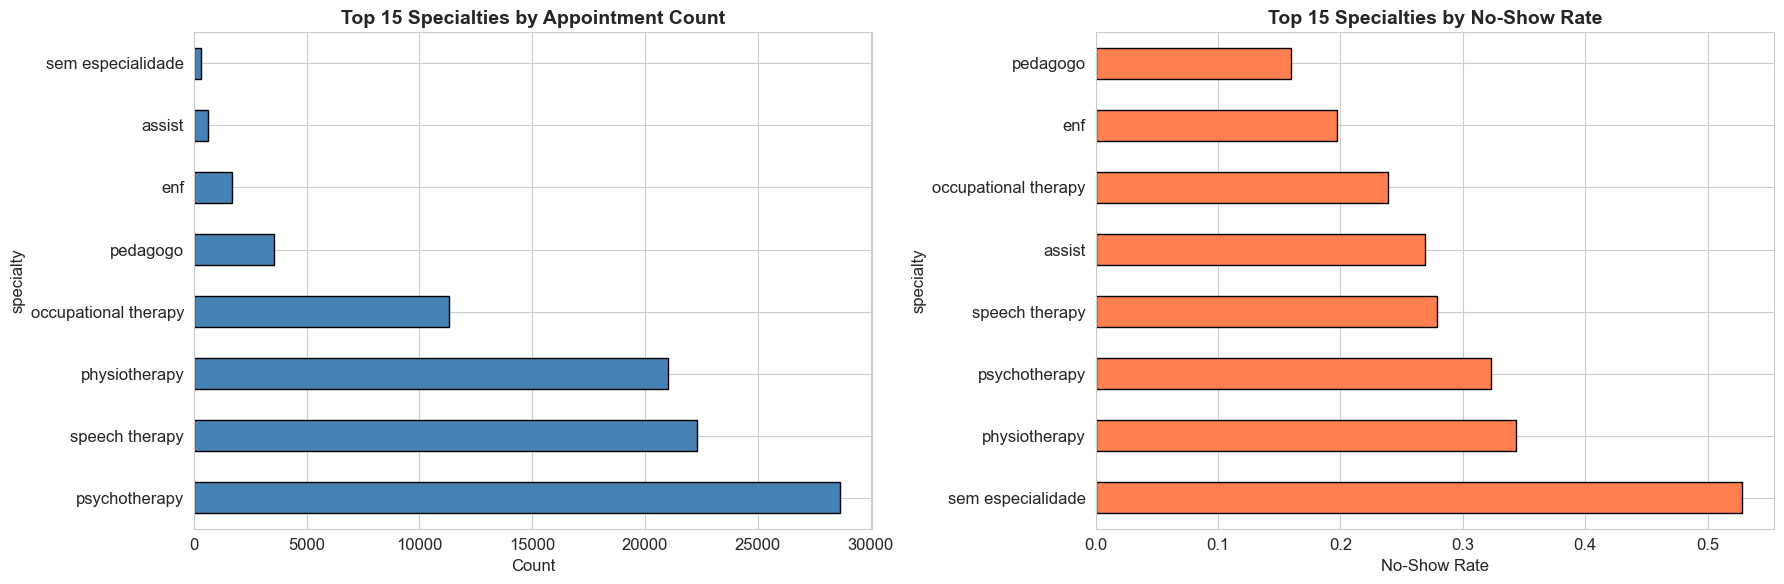

In [12]:
# ── No-Show Rate by Specialty ─────────────────────────────────────────────────
if 'specialty' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    specialty_counts = df['specialty'].value_counts().head(15)
    specialty_counts.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
    axes[0].set_title('Top 15 Specialties by Appointment Count', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Count')

    specialty_noshow = noshow_rate_by(df, 'specialty').sort_values(ascending=False).head(15)
    specialty_noshow.plot(kind='barh', ax=axes[1], color='coral', edgecolor='black')
    axes[1].set_title('Top 15 Specialties by No-Show Rate', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('No-Show Rate')

    plt.tight_layout()
    plt.show()

In [ ]:
# ── No-Show Rate by City (Place) ──────────────────────────────────────────────
if 'place' in df.columns:
    fig, ax = plt.subplots(figsize=(14, 6))
    place_noshow = noshow_rate_by(df.dropna(subset=['place']), 'place').sort_values(ascending=False)
    place_noshow.plot(kind='bar', ax=ax, color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(place_noshow))),
                      edgecolor='black')
    ax.set_title('No-Show Rate by City', fontsize=14, fontweight='bold')
    ax.set_ylabel('No-Show Rate')
    overall_rate = (df['no_show'] == 'yes').sum() / len(df)
    ax.axhline(y=overall_rate, color='red', linestyle='--', label='Overall Average')
    ax.legend()
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [ ]:
# ── No-Show Rate by Appointment Shift & Day of Week ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

if 'appointment_shift' in df.columns:
    shift_noshow = noshow_rate_by(df, 'appointment_shift')
    shift_noshow.plot(kind='bar', ax=axes[0], color='mediumpurple', edgecolor='black')
    axes[0].set_title('No-Show Rate by Appointment Shift', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('No-Show Rate')
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
    for i, v in enumerate(shift_noshow):
        axes[0].text(i, v + 0.005, f'{v:.1%}', ha='center', fontsize=11)

if 'appointment_date_continuous' in df.columns:
    df['_temp_date'] = pd.to_datetime(df['appointment_date_continuous'], errors='coerce')
    df['_day_of_week'] = df['_temp_date'].dt.day_name()
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    day_noshow = noshow_rate_by(df, '_day_of_week')
    day_noshow = day_noshow.reindex([d for d in day_order if d in day_noshow.index])
    day_noshow.plot(kind='bar', ax=axes[1], color='teal', edgecolor='black')
    axes[1].set_title('No-Show Rate by Day of Week', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('No-Show Rate')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
    for i, v in enumerate(day_noshow):
        axes[1].text(i, v + 0.005, f'{v:.1%}', ha='center', fontsize=10)
    df.drop(columns=['_temp_date', '_day_of_week'], inplace=True)

plt.tight_layout()
plt.show()

## Section 7: EDA - Weather Impact on Attendance

Analyze how weather conditions affect patient attendance:
- Temperature (avg/max) vs. no-show rate
- Rainfall impact
- Heat/rain intensity categories
- Storm and rainy day effects

In [ ]:
# ── Weather vs No-Show Analysis ───────────────────────────────────────────────
weather_num = ['avg_temp', 'max_temp', 'rain']
existing_weather_num = [c for c in weather_num if c in df.columns]

if existing_weather_num:
    fig, axes = plt.subplots(1, len(existing_weather_num), figsize=(6 * len(existing_weather_num), 5))
    if len(existing_weather_num) == 1:
        axes = [axes]
    for i, col in enumerate(existing_weather_num):
        df_w = df.dropna(subset=[col])
        sns.boxplot(data=df_w, x='no_show', y=col, ax=axes[i], palette=colors)
        axes[i].set_title(f'{col} by No-Show Status', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Weather categorical features
weather_cat = ['heat_intensity', 'rain_intensity', 'rainy_day_before', 'storm_day_before']
existing_weather_cat = [c for c in weather_cat if c in df.columns]

if existing_weather_cat:
    fig, axes = plt.subplots(1, len(existing_weather_cat), figsize=(5 * len(existing_weather_cat), 5))
    if len(existing_weather_cat) == 1:
        axes = [axes]
    for i, col in enumerate(existing_weather_cat):
        nr = noshow_rate_by(df, col).sort_values(ascending=False)
        nr.plot(kind='bar', ax=axes[i], color='darkorange', edgecolor='black')
        axes[i].set_title(f'No-Show Rate by {col}', fontsize=12, fontweight='bold')
        axes[i].set_ylabel('No-Show Rate')
        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
    plt.suptitle('Weather Conditions vs No-Show Rate', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [ ]:
# ── Correlation Heatmap (Numeric Features) ───────────────────────────────────
numeric_df = df.select_dtypes(include=[np.number])
if 'no_show' in df.columns and df['no_show'].dtype == 'object':
    numeric_df['no_show_encoded'] = df['no_show'].map({'yes': 1, 'no': 0})

if len(numeric_df.columns) > 2:
    fig, ax = plt.subplots(figsize=(16, 12))
    corr_matrix = numeric_df.corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, ax=ax, square=True, linewidths=0.5)
    ax.set_title('Correlation Heatmap - All Numeric Features', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Top correlations with target
    if 'no_show_encoded' in numeric_df.columns:
        target_corr = corr_matrix['no_show_encoded'].drop('no_show_encoded', errors='ignore').sort_values(key=abs, ascending=False)
        print('Top correlations with no_show:')
        print(target_corr.head(10).to_string())

## EDA Summary & Key Findings

### Key Observations:
1. **Class Imbalance:** ~31.8% no-show rate requires careful handling (SMOTE, class weights)
2. **Missing Values:** Significant missingness in age, specialty, disability, place — need strategic imputation
3. **Demographics & Health:** Certain patient groups may have higher no-show tendencies
4. **Temporal Patterns:** Day-of-week and shift variations suggest operational scheduling opportunities
5. **Geographic Variation:** Different cities show different no-show rates — useful for geographic resource planning
6. **Weather Effects:** Temperature and rainfall may influence attendance patterns

### Next Steps:
- **Notebook 02:** Feature engineering, encoding, and data preprocessing pipeline
- **Notebook 03:** No-show classification model training and evaluation
- **Notebook 04:** Demand forecasting model training and evaluation